![imagen](cardiovascular_diseases.jpg)

# Introduction

The objective of this notebook is to apply decision tree-based models and their interpretation techniques to predict cardiovascular disease (CVD) risk using clinical and lifestyle patient data.

Throughout this exercise, the following tasks will be addressed:

1. Exploratory Data Analysis (EDA): Explore and describe the dataset, identifying data quality issues such as missing values and duplicates. Generate visualizations to understand data distributions and answer key questions:
   - What is the mean age of patients?
   - What proportion of patients are smokers?
   - How many patients engage in physical activity?
   - Is the dataset balanced?

2. Data Preparation.

3. Decision Tree Modeling: Build a decision tree classifier and evaluate its accuracy on the test set.

4. Model Interpretation:
   - Generate feature importance table
   - Visualize the decision tree with depth = 3
   - Identify the seven most important features
   - Extract decision rules characterizing patients at risk for CVD
   - Identify characteristics of low-risk patients
   - Reflect on how these insights could guide lifestyle change recommendations

This exercise will provide hands-on experience with tree-based classification, model interpretability, and translating analytical insights into actionable medical recommendations for cardiovascular risk management.

# 1. Import libraries

In [46]:
# Data handling
import pandas as pd

# To prepare
from sklearn.preprocessing import LabelEncoder

# To create the decision tree
from sklearn.tree import DecisionTreeClassifier 

# To split the dataset into training and test sets
from sklearn.model_selection import train_test_split

# To evaluate the model
from sklearn.metrics import accuracy_score

# Libraries for visualizing the decision tree
import matplotlib.pyplot as plt
from sklearn import tree
from ydata_profiling import ProfileReport

# Confusion matrix library
from sklearn.metrics import ConfusionMatrixDisplay

# 2. Load data

In [4]:
data=pd.read_csv('enfermedad_cardiovascular_data.csv', sep=',', encoding = 'utf-8')

In [5]:
data.shape

(67976, 13)

In [6]:
data.head()

,Id,Edad,Género,Altura,Peso,Presion sistólica,Presión diastólica,Colesterol,Glucosa,Fumador,Alcohol,Activo,ECV
0,0,53,M,168,62.0,110,80,Normal,Normal,NO,NO,SI,NO
1,1,58,F,156,85.0,140,90,Muy elevado,Normal,NO,NO,SI,SI
2,2,54,F,165,64.0,130,70,Muy elevado,Normal,NO,NO,NO,SI
3,3,50,M,169,82.0,150,100,Normal,Normal,NO,NO,SI,SI
4,4,50,F,156,56.0,100,60,Normal,Normal,NO,NO,NO,NO


In [7]:
data.dtypes

Id                      int64
Edad                    int64
Género                 object
Altura                  int64
Peso                  float64
Presion sistólica       int64
Presión diastólica      int64
Colesterol             object
Glucosa                object
Fumador                object
Alcohol                object
Activo                 object
ECV                    object
dtype: object

# 3. EDA

In [8]:
data.describe()

,Id,Edad,Altura,Peso,Presion sistólica,Presión diastólica
count,67976.000000,67976.000000,67976.000000,67976.000000,67976.000000,67976.000000
mean,49954.764858,55.627913,164.555829,74.392564,126.731611,81.458794
std,28841.186196,7.047183,7.751991,14.032135,16.706251,9.624818
min,0.000000,31.000000,140.000000,48.000000,70.000000,50.000000
25%,24989.750000,50.000000,159.000000,65.000000,120.000000,80.000000
50%,49986.000000,56.000000,165.000000,72.000000,120.000000,80.000000
75%,74842.250000,61.000000,170.000000,82.000000,140.000000,90.000000
max,99999.000000,68.000000,198.000000,183.000000,240.000000,190.000000


Create a report

In [9]:
profile = ProfileReport(
    data, 
    title="Reporte de Análisis - Dataset Data",
    explorative=True  # Para análisis más detallado
)

# 3. Visualizar el reporte en el notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:01<00:00, 12.83it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

# 4. Data preparation

In [12]:
missing_values = data.isnull().sum().sum()
print(missing_values)

54


In [14]:
data_t = data
data_t=data_t.dropna()

In [15]:
data_t.shape

(67922, 13)

It is necessary to create dummy variables from the variables: 'Género','Colesterol', 'Glucosa', 'Fumador', 'Alcohol', 'Activo'

In [16]:
data_t = pd.get_dummies(data_t, columns=['Género','Colesterol', 'Glucosa', 'Fumador', 'Alcohol', 'Activo',])

The categories must be converted into numbers, since decision trees **ONLY** recognize numbers.

In [19]:
encoding = LabelEncoder()

In [20]:
data_t['ECV']=encoding.fit_transform(data_t['ECV'])

In [21]:
data_t.head()

,Id,Edad,Altura,Peso,Presion sistólica,Presión diastólica,ECV,Género_F,Género_M,Colesterol_Elevado,...,Colesterol_Normal,Glucosa_Elevado,Glucosa_Muy elevado,Glucosa_Normal,Fumador_NO,Fumador_SI,Alcohol_NO,Alcohol_SI,Activo_NO,Activo_SI
0,0,53,168,62.0,110,80,0,False,True,False,...,True,False,False,True,True,False,True,False,False,True
1,1,58,156,85.0,140,90,1,True,False,False,...,False,False,False,True,True,False,True,False,False,True
2,2,54,165,64.0,130,70,1,True,False,False,...,False,False,False,True,True,False,True,False,True,False
3,3,50,169,82.0,150,100,1,False,True,False,...,True,False,False,True,True,False,True,False,False,True
4,4,50,156,56.0,100,60,0,True,False,False,...,True,False,False,True,True,False,True,False,True,False


Remove the “Id” variable, since it is an identifier.

In [24]:
data_t = data_t.drop(['Id'], axis=1)

In [25]:
data_t.shape

(67922, 20)

# 5. Model Building

In [26]:
Y=data_t['ECV']
X=data_t.drop(['ECV'], axis=1)

In [27]:
Y.head()

0    0
1    1
2    1
3    1
4    0
Name: ECV, dtype: int64

In [28]:
X.head()

,Edad,Altura,Peso,Presion sistólica,Presión diastólica,Género_F,Género_M,Colesterol_Elevado,Colesterol_Muy elevado,Colesterol_Normal,Glucosa_Elevado,Glucosa_Muy elevado,Glucosa_Normal,Fumador_NO,Fumador_SI,Alcohol_NO,Alcohol_SI,Activo_NO,Activo_SI
0,53,168,62.0,110,80,False,True,False,False,True,False,False,True,True,False,True,False,False,True
1,58,156,85.0,140,90,True,False,False,True,False,False,False,True,True,False,True,False,False,True
2,54,165,64.0,130,70,True,False,False,True,False,False,False,True,True,False,True,False,True,False
3,50,169,82.0,150,100,False,True,False,False,True,False,False,True,True,False,True,False,False,True
4,50,156,56.0,100,60,True,False,False,False,True,False,False,True,True,False,True,False,True,False


In [33]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [34]:
Tree = DecisionTreeClassifier(criterion='entropy', random_state = 0)
Tree

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [35]:
Tree = Tree.fit(X_train,Y_train)

In [36]:
y_pred = Tree.predict(X_test)
print('Accuracy: %.2f' % accuracy_score(Y_test, y_pred))

Accuracy: 0.64


# 6. Models interpretation

In [37]:
importance = Tree.feature_importances_
importance

array([0.16280678, 0.21759579, 0.23377162, 0.192694  , 0.05748325,
       0.01394884, 0.01430261, 0.00747458, 0.01411305, 0.01221781,
       0.00916812, 0.00736882, 0.0109157 , 0.00729046, 0.0066246 ,
       0.00614639, 0.00604363, 0.01067173, 0.00936225])

In [38]:
attribute_importance = pd.DataFrame(data={"Attribute": X_train.columns,"Importance": importance})
attribute_importance = attribute_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True)
attribute_importance

,Attribute,Importance
0,Peso,0.233772
1,Altura,0.217596
2,Presion sistólica,0.192694
3,Edad,0.162807
4,Presión diastólica,0.057483
5,Género_M,0.014303
6,Colesterol_Muy elevado,0.014113
7,Género_F,0.013949
8,Colesterol_Normal,0.012218
9,Glucosa_Normal,0.010916


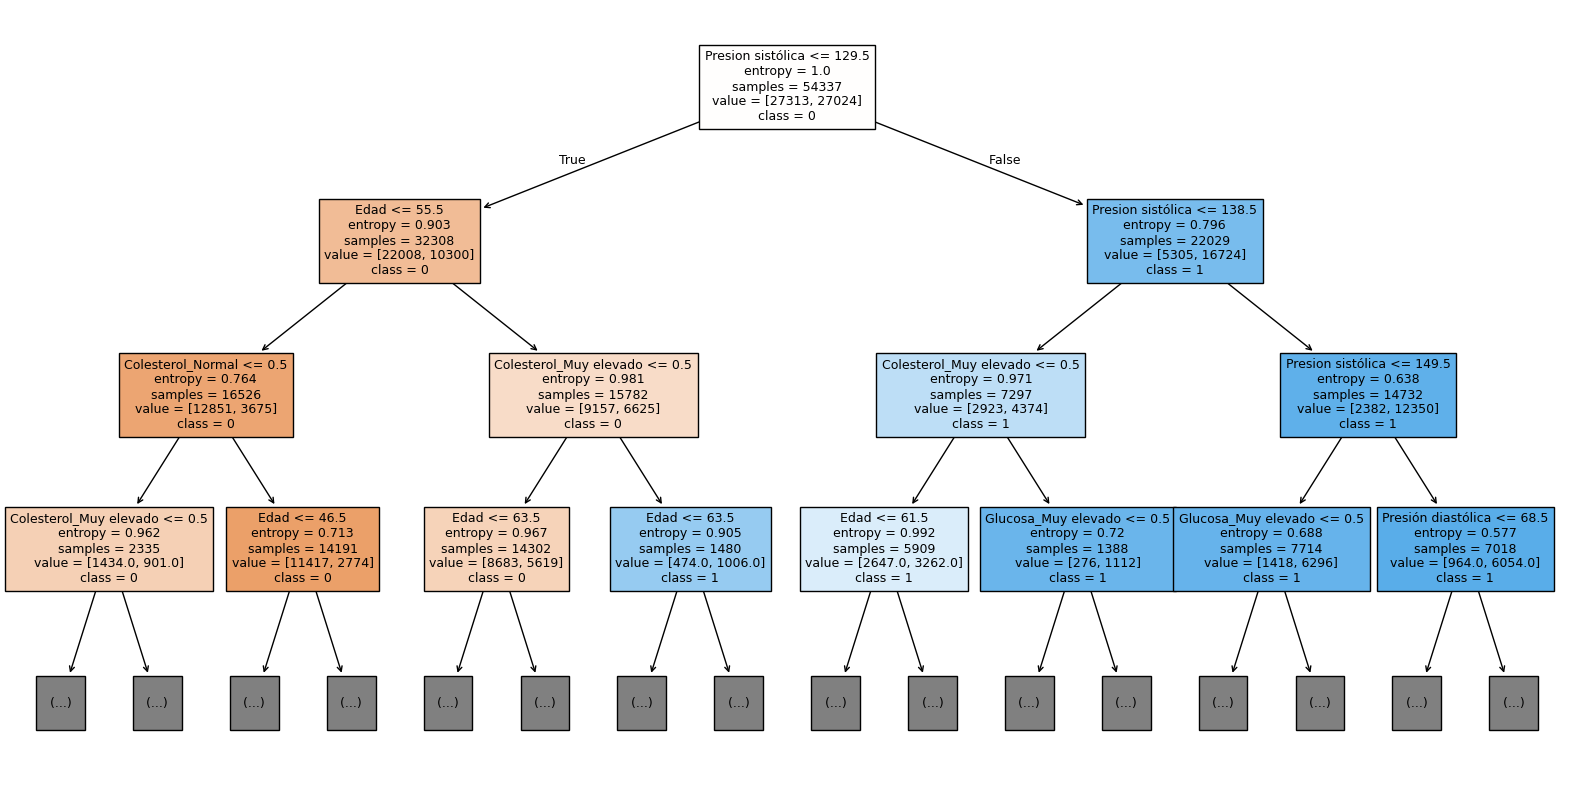

In [39]:
%matplotlib inline
fig = plt.figure(figsize=(20,10))
_ = tree.plot_tree(arbol, max_depth=3, feature_names=X.columns, class_names=["0", "1"], filled=True, fontsize=9)
plt.show()

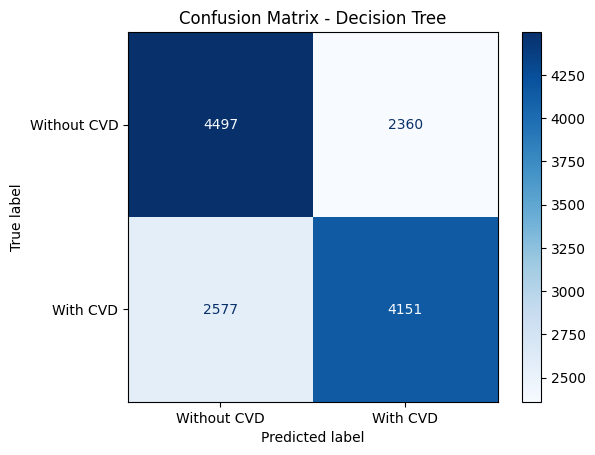

In [48]:
ConfusionMatrixDisplay.from_estimator(Tree, X_test, Y_test, 
                                       display_labels=['Without CVD', 'With CVD'],
                                       cmap='Blues')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

### Interpretation:
- **True Positives (TP):** 4,151 CVD patients correctly identified
- **False Negatives (FN):** 2,577 CVD patients missed (critical error)
- **True Negatives (TN):** 4,497 healthy patients correctly classified
- **False Positives (FP):** 2,360 healthy patients incorrectly flagged as at risk

# 7. Conclusions

### Feature Importance Analysis

The decision tree identified the following seven most important variables for predicting cardiovascular disease (CVD) risk:

| Rank | Variable | Importance |
|------|----------|------------|
| 1 | **Weight** | 0.234 |
| 2 | **Height** | 0.218 |
| 3 | **Systolic blood pressure** | 0.193 |
| 4 | **Age** | 0.163 |
| 5 | **Diastolic blood pressure** | 0.057 |
| 6 | **Gender_M** | 0.014 |
| 7 | **Cholesterol_Very high** | 0.014 |

Key insight: Physical attributes (weight, height, blood pressure, and age) dominate the model, accounting for 86.5% of total importance. Lifestyle factors (smoking, alcohol, physical activity) have minimal influence according to this tree.

The root node splits on systolic blood pressure ≤ 129.5, indicating this is the most critical differentiator.

**Patients at higher risk (developing CVD) are characterized by:**
- Systolic blood pressure > 129.5 mm Hg
- High glucose levels
- Elevated diastolic pressure

**Patients at lower risk (no CVD) are characterized by:**
- Systolic blood pressure ≤ 129.5 mm Hg
- Lower cholesterol and younger age

### Model Performance Summary

| Metric | Value |
|--------|-------|
| Accuracy | 64% |
| True Positives (CVD correctly identified) | 4,151 |
| False Negatives (CVD missed) | 2,577 |
| True Negatives (Healthy correctly identified) | 4,497 |
| False Positives (Healthy incorrectly flagged) | 2,360 |

### Limitations

- The model's accuracy (64%) is moderate, suggesting room for improvement
- Lifestyle factors showed low importance, possibly due to data quality or imbalanced representation
- Further refinement with ensemble methods (Random Forest, XGBoost) could improve predictive performance